### Importing Data from 2022 and 2023

In [1]:
import pandas as pd

In [6]:
data_uda = pd.read_csv('WeeklyPastDataFW22.csv',dtype={"ItemCode":object})

In [7]:
data_uda.head()

,H1,H2,H3,H4,H5,ItemCode,WeekStartDate,SeasonPeriod,ActualPrice,FirstPrice,...,SalesRevenue,SalesRevenueonPrice,ExpectedSalesRevenue,DiscountRate,DiscountRateOnPrice,StoreStock,StoreIncomingStock,DistinctStoreCount,Brand,Material
0,AYAKKABI,ERKEK,DRESS,AYAKKABI,FORMAL MASKARETLI,000000000101201710,2023-01-05,Season4,409.99,679.99,...,-2200.0,-819.98,-1359.98,0.000000,0.397065,194,8,37,INCI,DERI
1,AYAKKABI,ERKEK,CASUAL,BOT,MILITARY BOT,000000000101040906,2023-02-23,Season4,899.99,899.99,...,0.0,0.00,0.00,0.000000,0.000000,22,0,14,LUMBERJACK,DERI
2,AYAKKABI,AKTIFSPOR,ATHLETIC,AYAKKABI,KOSU,000000000101084317,2023-01-05,Season4,299.99,479.99,...,9925.0,12599.58,20159.58,0.464868,0.375008,421,10,175,LUMBERJACK,TEKSTIL
3,AYAKKABI,ERKEK,CASUAL,BOT,WORKER BOT,000000000101208167,2022-12-08,Season3,769.99,769.99,...,0.0,0.00,0.00,0.000000,0.000000,2,0,2,U.S. Polo Assn.,PU
4,AYAKKABI,KADIN,CASUAL,AYAKKABI,HAVUZ TABAN SNEAKER,000000000101190782,2022-10-27,Season2,319.99,319.99,...,2736.0,2879.91,2879.91,-0.032640,0.000000,62,296,40,POLARIS,NaN


In [8]:
#order columns
data_uda = data_uda.groupby("ItemCode",as_index=False).apply(lambda x: x.sort_values("WeekStartDate",ascending=True))

In [15]:
# Lag Discount Rate
data_uda['DiscountRateLag'] = data_uda.groupby('ItemCode',as_index=False)['DiscountRateOnPrice'].shift(1)
data_uda["PrevSales"] = data_uda.groupby('ItemCode',as_index=False)['Sales'].shift(1)
data_uda["PrevPrice"] = data_uda.groupby('ItemCode',as_index=False)['ActualPrice'].shift(1)

In [16]:
data_uda.reset_index(drop=True,inplace=True)

In [18]:
condition = ((data_uda.DiscountRateOnPrice-data_uda.DiscountRateLag>=0.1) &
            (data_uda.Sales>0) & (data_uda.PrevSales>0))

In [30]:
data = data_uda[condition]

In [54]:
data.dtypes

H1                       object
H2                       object
H3                       object
H4                       object
H5                       object
ItemCode                 object
WeekStartDate            object
SeasonPeriod             object
ActualPrice             float64
FirstPrice              float64
Sales                     int64
SalesRevenue            float64
SalesRevenueonPrice     float64
ExpectedSalesRevenue    float64
DiscountRate            float64
DiscountRateOnPrice     float64
StoreStock                int64
StoreIncomingStock        int64
DistinctStoreCount        int64
Brand                    object
Material                 object
DiscountRateLag         float64
PrevSales               float64
PrevPrice               float64
Fraction                float64
dtype: object

In [65]:
data["WeekStartStock"] = data_uda.StoreStock + data_uda.StoreIncomingStock

/var/folders/yg/bj8skk0s5nz2vzh6qqntb11w0000gn/T/ipykernel_20266/295264296.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["WeekStartStock"] = data_uda.StoreStock + data_uda.StoreIncomingStock


In [66]:
data.dtypes

H1                       object
H2                       object
H3                       object
H4                       object
H5                       object
ItemCode                 object
WeekStartDate            object
SeasonPeriod             object
ActualPrice             float64
FirstPrice              float64
Sales                     int64
SalesRevenue            float64
SalesRevenueonPrice     float64
ExpectedSalesRevenue    float64
DiscountRate            float64
DiscountRateOnPrice     float64
StoreStock                int64
StoreIncomingStock        int64
DistinctStoreCount        int64
Brand                    object
Material                 object
DiscountRateLag         float64
PrevSales               float64
PrevPrice               float64
Fraction                float64
week_start_stock          int64
WeekStartStock            int64
dtype: object

In [24]:
from matplotlib import pyplot as plt

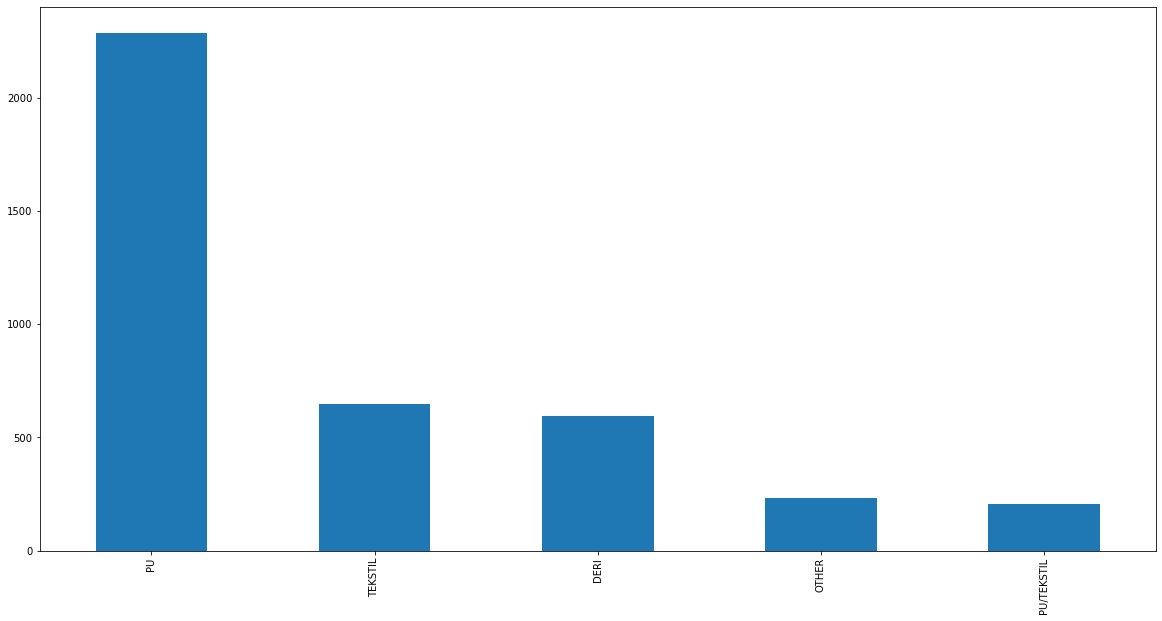

In [35]:
#plot Material count higher than 100
data.Material.value_counts()[data.Material.value_counts()>100].plot(kind='bar',figsize=(20,10))
plt.show()

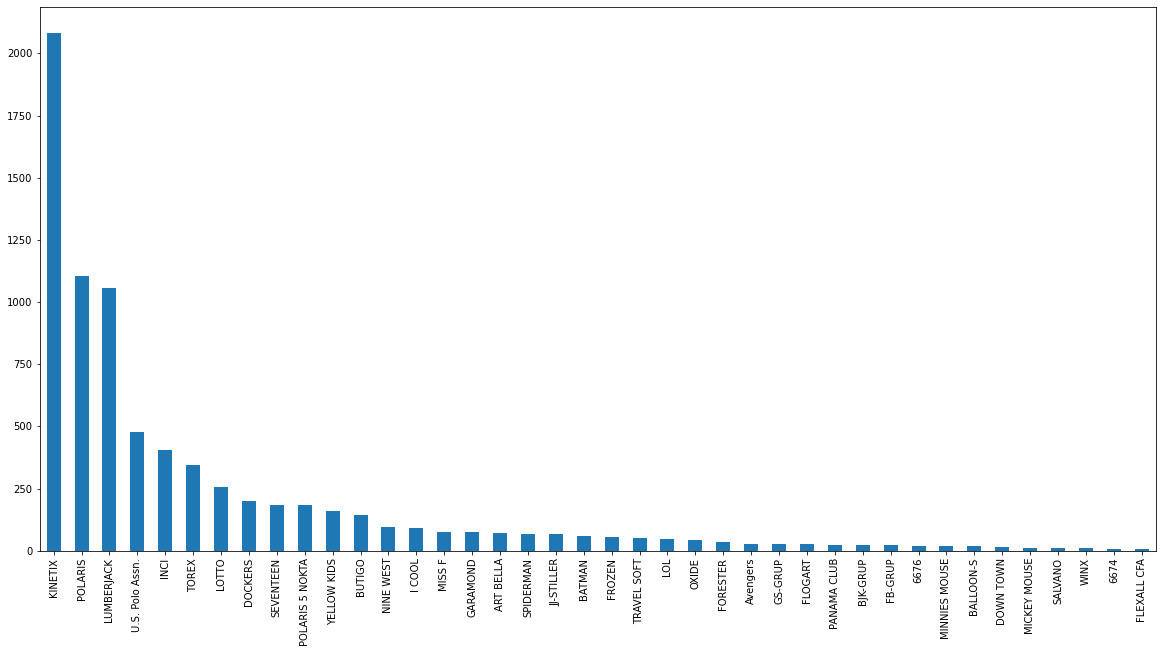

In [34]:
data.Brand.value_counts().plot(kind='bar',figsize=(20,10))
plt.show()

In [38]:
from matplotlib import pyplot as plt

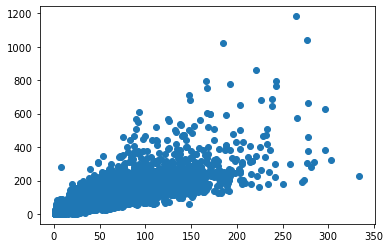

In [40]:
plt.scatter(data.PrevSales,data.Sales)

In [41]:
data["Fraction"] = data.Sales/data.PrevSales

/var/folders/yg/bj8skk0s5nz2vzh6qqntb11w0000gn/T/ipykernel_20266/3783783591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Fraction"] = data.Sales/data.PrevSales


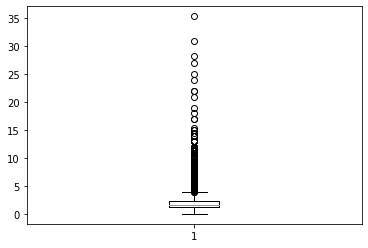

In [44]:
plt.boxplot(data.Fraction)
plt.show()

In [67]:
lower_limit = data["Fraction"].quantile(0.1)
upper_limit = data["Fraction"].quantile(0.9)

filtered_data = data[(data["Fraction"]>lower_limit)&(data["Fraction"]<upper_limit)]

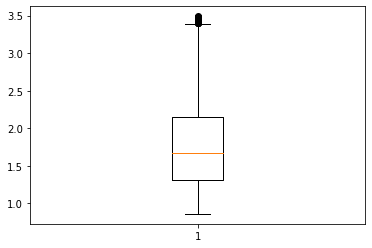

In [47]:
plt.boxplot(filtered_data.Fraction)
plt.show()

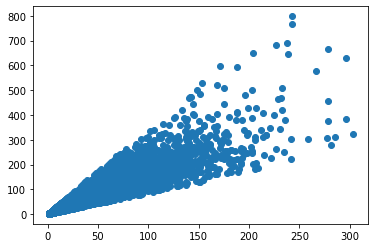

In [48]:
plt.scatter(filtered_data["PrevSales"],filtered_data["Sales"])
plt.show()

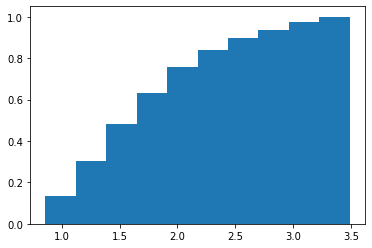

In [49]:
plt.hist(filtered_data["Fraction"],bins=10,density=True,cumulative=True)
plt.show()

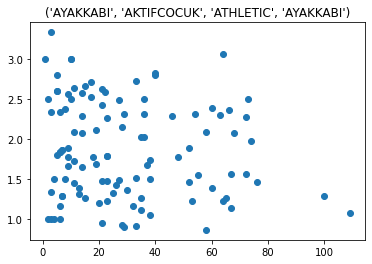

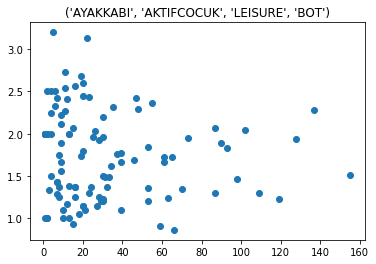

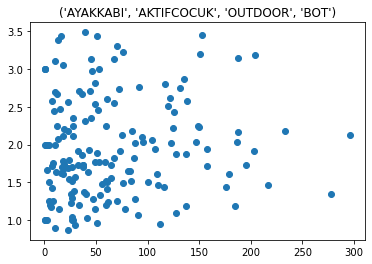

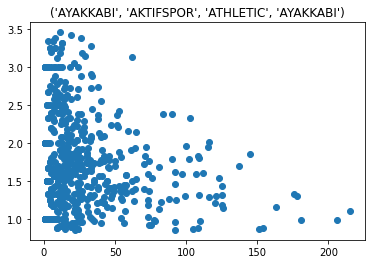

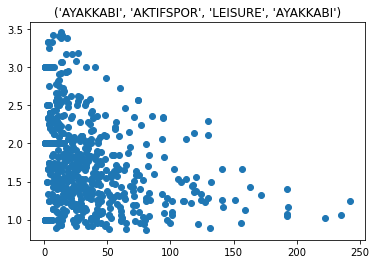

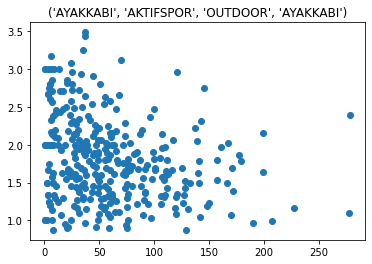

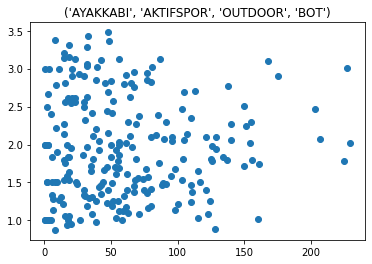

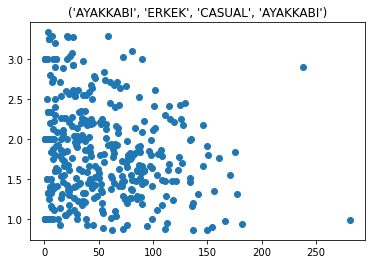

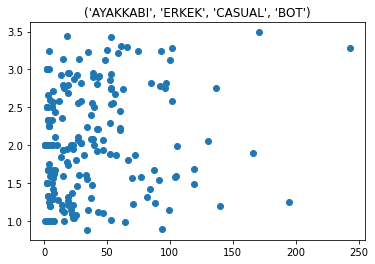

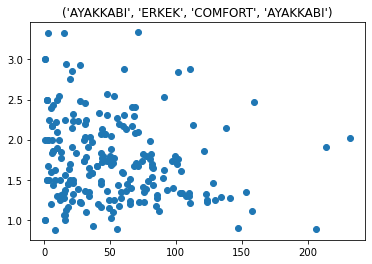

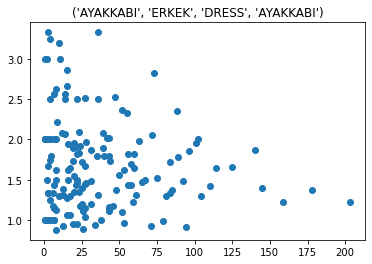

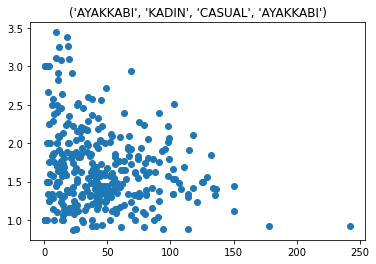

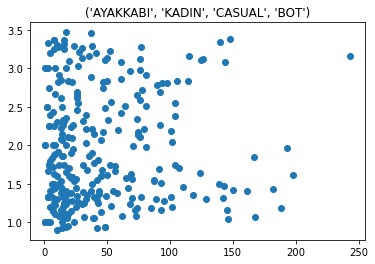

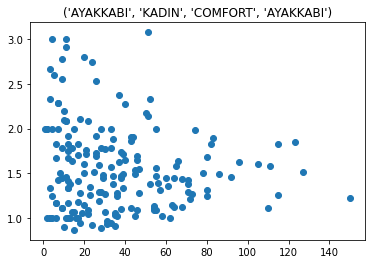

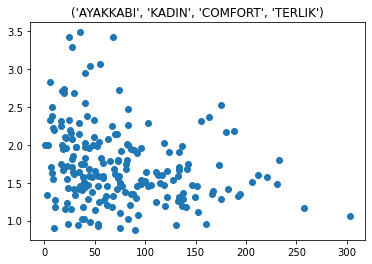

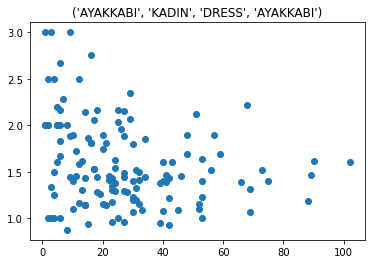

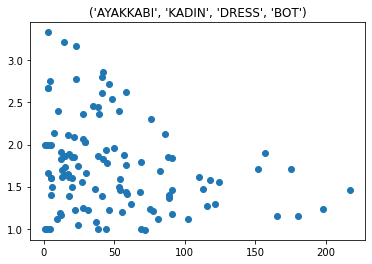

In [50]:
for key, values in filtered_data.groupby(["H1","H2","H3","H4"]):
    if len(values)<100:
        continue
    plt.scatter(values["PrevSales"],values["Fraction"])
    plt.title(key)
    plt.show()

In [52]:
filtered_data[["Sales","PrevSales"]].corr()

,Sales,PrevSales
Sales,1.000000,0.898486
PrevSales,0.898486,1.000000


In [68]:
filtered_data[["Sales","WeekStartStock"]].corr()

,Sales,WeekStartStock
Sales,1.000000,0.739421
WeekStartStock,0.739421,1.000000


In [70]:
import seaborn as sns

/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


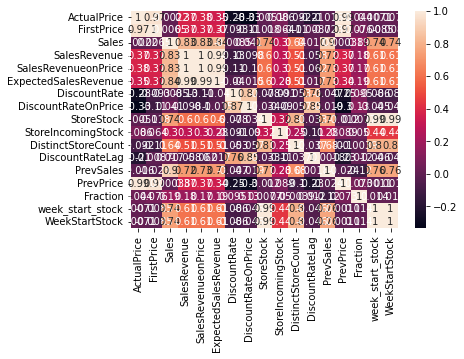

In [71]:
sns.heatmap(filtered_data.corr(),annot=True)
plt.show()

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


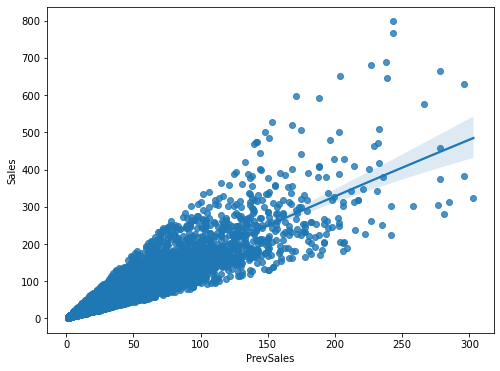

In [72]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
scatter = sns.regplot(filtered_data['PrevSales'], filtered_data['Sales'], order=2)
plt.show()

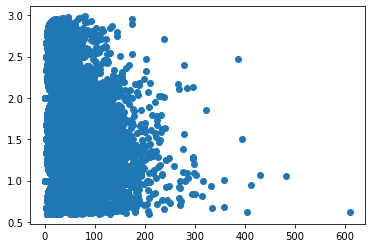

In [131]:
plt.scatter(data3.PrevSales,data3.Fraction)
plt.show()

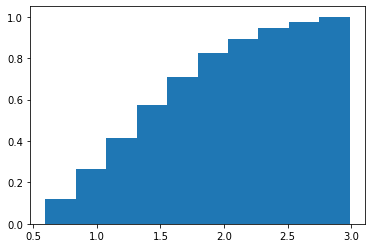

In [132]:
plt.hist(data3.Fraction,density=True,cumulative=1)
plt.show()

In [75]:
filtered_data.dtypes

H1                       object
H2                       object
H3                       object
H4                       object
H5                       object
ItemCode                 object
WeekStartDate            object
SeasonPeriod             object
ActualPrice             float64
FirstPrice              float64
Sales                     int64
SalesRevenue            float64
SalesRevenueonPrice     float64
ExpectedSalesRevenue    float64
DiscountRate            float64
DiscountRateOnPrice     float64
StoreStock                int64
StoreIncomingStock        int64
DistinctStoreCount        int64
Brand                    object
Material                 object
DiscountRateLag         float64
PrevSales               float64
PrevPrice               float64
Fraction                float64
week_start_stock          int64
WeekStartStock            int64
dtype: object

In [79]:
from sklearn.model_selection import train_test_split

In [134]:
features = ["PrevSales","WeekStartStock","DiscountRateOnPrice","DiscountRateLag"]

In [135]:
X = filtered_data
#X["H5"] = X["H5"].astype("category")
y = filtered_data

In [136]:
X= pd.get_dummies(X,columns=["H5","Brand","Material"],drop_first=True)
trainX,testX,trainY, testY = train_test_split(X,y,train_size=round(len(filtered_data)*0.75))

In [137]:
features = features+X.loc[:,X.columns.str.startswith('H5')].columns.tolist() +\
X.loc[:,X.columns.str.startswith('Brand')].columns.tolist() +\
X.loc[:,X.columns.str.startswith('Material')].columns.tolist()

In [138]:
#remove duplicates from features
features = list(set(features))

In [139]:
import xgboost as xgb 

In [140]:

def_params = {
            "learning_rate": 0.05,
            "n_estimators": 100,
            "max_depth": 6,
            "booster": "gbtree",
            "min_child_weight": 4,
            "subsample": 1,
            "colsample_bytree": 0.85,
            "grow_policy": "lossguide",
            "eval_metric": "mae",
            "importance_type": "weight",
            "verbosity": 2,
            "n_jobs": 1,
            "enable_categorical": True
          }


In [141]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error

In [142]:
trainY

,H1,H2,H3,H4,H5,ItemCode,WeekStartDate,SeasonPeriod,ActualPrice,FirstPrice,...,StoreIncomingStock,DistinctStoreCount,Brand,Material,DiscountRateLag,PrevSales,PrevPrice,Fraction,week_start_stock,WeekStartStock
88146,AYAKKABI,AKTIFSPOR,LEISURE,BOT,SNEAKER HI,000000000101088638,2022-12-08,Season3,399.99,499.99,...,4,61,KINETIX,PU,0.000000,6.0,499.99,1.500000,235,235
176493,AYAKKABI,COCUK,NaN,AYAKKABI,ATHLETIC,000000000101175220,2022-12-15,Season3,239.99,339.99,...,10,141,FROZEN,NaN,0.000000,44.0,339.99,2.295455,1009,1009
211673,AYAKKABI,COCUK,NaN,AYAKKABI,BASIC GUNLUK AYAKKABI,000000000101190335,2022-12-08,Season3,219.99,279.99,...,10,304,POLARIS,PU,0.000000,50.0,279.99,1.440000,1696,1696
225694,AYAKKABI,KADIN,DRESS,AYAKKABI,LOAFER,000000000101194689,2022-11-10,Season3,529.00,659.00,...,82,41,NINE WEST,NaN,0.000000,14.0,659.00,1.142857,355,355
131418,AYAKKABI,AKTIFSPOR,LEISURE,BOT,SNEAKER HI,000000000101165392,2023-02-02,Season4,449.99,549.99,...,78,44,LUMBERJACK,OTHER,0.000000,9.0,549.99,0.888889,196,196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123641,AYAKKABI,AKTIFSPOR,ATHLETIC,AYAKKABI,BASKETBOL,000000000101164000,2022-12-15,Season3,409.99,489.99,...,19,141,KINETIX,PU,0.000000,16.0,489.99,1.875000,658,658
140717,AYAKKABI,AKTIFCOCUK,OUTDOOR,BOT,OUTDOOR HI,000000000101168230,2023-01-05,Season4,329.99,559.99,...,14,122,LUMBERJACK,NaN,0.000000,27.0,559.99,1.703704,871,871
246348,AYAKKABI,KADIN,COMFORT,TERLIK,EV ICI TERLIK,000000000101199977,2022-12-08,Season3,119.99,189.99,...,31,279,POLARIS,TEKSTIL,0.205452,128.0,149.99,1.531250,2042,2042
205483,AYAKKABI,KADIN,COMFORT,AYAKKABI,GELENEKSEL COMFORT DUZ,000000000101187258,2022-12-15,Season3,289.99,449.99,...,9,41,POLARIS,NaN,0.217217,7.0,349.99,2.285714,187,187


In [143]:
def objective(trial):
    params = {
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        "booster": "gbtree",
        "grow_policy": "lossguide",
        "eval_metric": "mae",
        "importance_type": "weight",
        "enable_categorical": True
    }

    model = xgb.XGBRegressor(**params)
    model.fit(trainX[features],trainY["Sales"])
    pred = model.predict(testX[features])
    mape = mean_absolute_percentage_error(testY["Sales"], pred)
    return mape


In [144]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print('Number of finished trials: ', len(study.trials))
print('Best trial:')
trial = study.best_trial

print('Value: ', trial.value)
print('Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')


[I 2023-11-30 09:28:38,074] A new study created in memory with name: no-name-5f116647-fce4-496b-a47a-1cf3a5d948db
[I 2023-11-30 09:28:39,178] Trial 0 finished with value: 0.33740580811506155 and parameters: {'colsample_bytree': 0.9310337505278201, 'subsample': 0.39298044536270527, 'learning_rate': 0.14506380925655168, 'max_depth': 15, 'n_estimators': 99, 'min_child_weight': 3}. Best is trial 0 with value: 0.33740580811506155.
[I 2023-11-30 09:28:39,648] Trial 1 finished with value: 0.4647704298638583 and parameters: {'colsample_bytree': 0.6599839308226938, 'subsample': 0.5138074423167939, 'learning_rate': 0.2151415540543696, 'max_depth': 12, 'n_estimators': 78, 'min_child_weight': 7}. Best is trial 0 with value: 0.33740580811506155.
[I 2023-11-30 09:28:39,821] Trial 2 finished with value: 1.2341253541108652 and parameters: {'colsample_bytree': 0.3495105095849832, 'subsample': 0.13085636145051951, 'learning_rate': 0.03429158589123432, 'max_depth': 6, 'n_estimators': 66, 'min_child_weigh

Number of finished trials:  100
Best trial:
Value:  0.2882624465286561
Params: 
    colsample_bytree: 0.9740707964037196
    subsample: 0.7528315980721075
    learning_rate: 0.03882803169646097
    max_depth: 15
    n_estimators: 276
    min_child_weight: 1


In [145]:
best_params = study.best_params
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(trainX[features],trainY["Sales"])
pred = final_model.predict(testX[features])
mape = mean_absolute_percentage_error(testY["Sales"], pred)
mape

0.2882624465286561

In [249]:
best_params

{'colsample_bytree': 0.9977736188142261,
 'subsample': 0.5891693443179318,
 'learning_rate': 0.06529345497247825,
 'max_depth': 14,
 'n_estimators': 150,
 'min_child_weight': 1}

In [146]:
base_model = xgb.XGBRegressor(**def_params)
base_model.fit(trainX[features],trainY["Sales"])
pred = base_model.predict(testX[features])
mape_base = mean_absolute_percentage_error(testY["Sales"], pred)
mape_base

0.3421234355502329

In [147]:
modeldict = {}
pred = []
actual = []
for key, item in trainX.groupby(["H1","H2","H3","H4"]):
    X = trainX[features]
    y = trainX["Sales"]

    if len(trainX)<20:
        modeldict[key] = final_model
        continue
    model = xgb.XGBRegressor(**best_params)
    model.fit(X,y)
    modeldict[key] = model
    



In [148]:
for key, item in testX.groupby(["H1","H2","H3","H4"]):
    if key not in modeldict:
        continue
    model = modeldict[key]
    pred.extend(model.predict(item[features]))
    actual.extend(item["Sales"])

In [149]:
results = pd.DataFrame({"Actual":actual,"Predicted":pred})

In [150]:
mean_absolute_percentage_error(results["Actual"],results["Predicted"])

0.2775237927443511

In [151]:
sum(abs(results.Actual-results.Predicted))/sum(results.Actual)

0.2272918329290153

In [180]:
price_elasticity = pd.DataFrame(columns=["H1","H2","H3","H4","price_elasticity"])

In [186]:
header=[]
Sales =[]
ActualSales =[]
PrevSales =[]
MdLoss =[]
PrevMdLoss =[]
ItemCount=[]
MAPE = []

In [187]:
for indicies, values in result.groupby(by=["H1","H2","H3","H4"]):
    header.append(indicies)
    Sales.append(np.sum(values.Pred))
    ActualSales.append(np.sum(values.Sales))
    PrevSales.append(np.sum(values.PrevSales))
    MdLoss.append(1-(np.sum(values.Sales*values.Price)/np.sum(values.Sales*values.FirstPrice)))
    PrevMdLoss.append(1-(np.sum((1-values.PrevDiscountRate)*values.FirstPrice*values.PrevSales)/np.sum(values.PrevSales*values.FirstPrice)))
    ItemCount.append(values["H1"].count())
    MAPE.append(np.sum(values.abs_error)/np.sum(values.Sales))

    

In [188]:
elasticity = np.log(np.array(Sales)/np.array(PrevSales))/np.log(1-(np.array(MdLoss)-np.array(PrevMdLoss)))

In [189]:
pd.DataFrame(data={
    "hierarchy":header,
    "price_elasticity": elasticity,
    "item_count":ItemCount,
    "sales":Sales,
    "prev_sales":PrevSales,
    "actual_sales":ActualSales,
    "MAPE":MAPE
}).sort_values("price_elasticity",ignore_index=True)

,hierarchy,price_elasticity,item_count,sales,prev_sales,actual_sales,MAPE
0,"(AYAKKABI, AKTIFSPOR, OUTDOOR, SANDALET)",-3.811268,1,18.0,11,19,0.052632
1,"(AYAKKABI, AKTIFSPOR, OUTDOOR, KURKLU BOT)",-2.486597,1,14.0,9,24,0.416667
2,"(AYAKKABI, KADIN, DRESS, CIZME)",-2.448809,2,68.0,44,76,0.210526
3,"(AYAKKABI, AKTIFSPOR, LEISURE, KURKLU AYAKKABI)",-2.420424,3,93.0,46,78,0.192308
4,"(AYAKKABI, ERKEK, DRESS, BOT)",-2.376815,15,751.0,499,739,0.370771
5,"(AYAKKABI, KADIN, DRESS, AYAKKABI)",-2.257756,57,1844.0,1145,1511,0.407015
6,"(AYAKKABI, KADIN, COMFORT, AYAKKABI)",-2.229876,86,3940.0,2610,3677,0.246668
7,"(AYAKKABI, KADIN, CASUAL, AYAKKABI)",-2.160490,236,14272.0,9172,13297,0.250808
8,"(AYAKKABI, KADIN, CASUAL, BOT)",-2.159311,85,5003.0,3240,5862,0.346469
9,"(AYAKKABI, KADIN, DRESS, BOT)",-1.993152,37,2482.0,1651,2510,0.232669


In [109]:
trainX

,PrevSales,Stock,Price,DiscountOnPrice,PrevDiscountRate
2341,93,1360,537.0278,0.147061,0.000000
1156,53,585,462.9537,0.264710,0.000000
4606,6,156,611.1019,0.204822,0.000000
5030,21,663,129.9900,0.350018,0.000000
2759,2,141,351.8426,0.309097,0.000000
...,...,...,...,...,...
4412,75,1700,462.9537,0.166669,0.000000
3090,10,358,399.9900,0.200004,0.000000
6845,53,1980,289.9900,0.420008,0.275368
6348,3,179,999.9900,0.254490,0.000000
